In [16]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
"D:\Users\Admin\Projects\dso\SAR_ML\data\DSO\mstar\npy_noscaling_files\real\2s1\2s1_real_elevDeg_15_azCenter_0_sn_b01.npy"

In [3]:
arr = np.load("/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/real/2s1/2s1_real_elevDeg_15_azCenter_0_sn_b01.npy")

In [56]:
def dso_np_file_loader(path):
    arr = np.load(path)
    complex_arr = arr[:, :, 0] + 1j * arr[:, :, 1]
    # complex_arr[complex_arr < 1e-17] = 0
    return complex_arr

In [15]:
real_test = dso_np_file_loader("/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/real/2s1/2s1_real_elevDeg_15_azCenter_0_sn_b01.npy")

In [31]:
np.abs(real_test)

array([[0.06270671, 0.09226845, 0.03851984, ..., 0.00716648, 0.07256063,
        0.08151874],
       [0.07076901, 0.12810086, 0.09226845, ..., 0.05195699, 0.08958102,
        0.09316426],
       [0.09764332, 0.09316426, 0.03045755, ..., 0.06449833, 0.13705896,
        0.16124584],
       ...,
       [0.01881201, 0.04837375, 0.03404079, ..., 0.01612458, 0.03941565,
        0.05106118],
       [0.03583241, 0.05106118, 0.0170204 , ..., 0.03583241, 0.02866593,
        0.01343715],
       [0.04210308, 0.02149945, 0.02149945, ..., 0.06001928, 0.02956174,
        0.03314498]], shape=(128, 128))

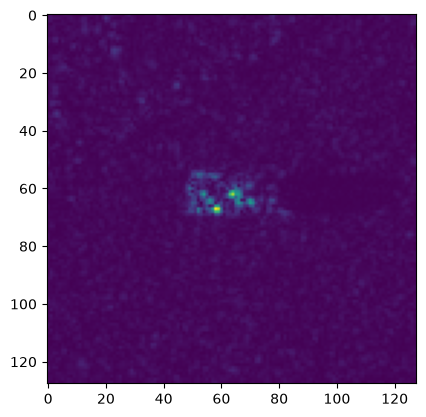

In [19]:
plt.imshow(np.abs(real_test))
plt.show()

In [22]:
synth_test = dso_np_file_loader("/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/synth/2s1/2s1_synth_elevDeg_15_azCenter_0.npy")

In [49]:
np.abs(synth_test)

array([[2.39895044e-18, 9.90844530e-18, 6.20936508e-18, ...,
        2.95953434e-17, 9.30268209e-18, 1.44376084e-17],
       [1.78903625e-18, 1.37283287e-17, 4.90653893e-18, ...,
        2.36624485e-17, 5.07841964e-18, 1.36071692e-17],
       [2.38154577e-18, 7.02726957e-18, 7.75791923e-18, ...,
        2.11971923e-17, 8.84011307e-18, 5.94336649e-18],
       ...,
       [8.10345933e-18, 6.77778129e-18, 7.15244812e-18, ...,
        2.71050543e-18, 9.30284004e-18, 1.05522243e-17],
       [8.09547706e-18, 1.14096826e-17, 9.67069442e-18, ...,
        1.72657281e-17, 4.75197290e-18, 1.43987804e-17],
       [6.20652478e-18, 6.42155291e-18, 9.35434656e-18, ...,
        1.71564503e-17, 6.87955967e-18, 1.03915278e-17]], shape=(128, 128))

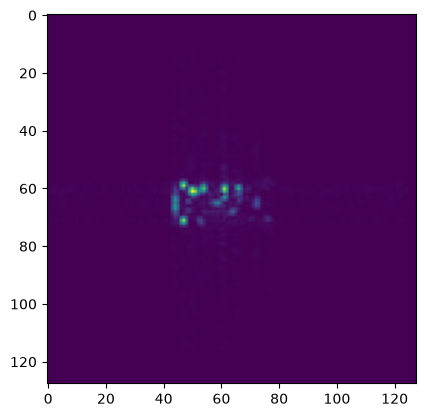

In [24]:
plt.imshow(np.abs(synth_test))
plt.show()

In [87]:
20*np.log10(1 + np.abs(synth_test) / (1 + np.abs(synth_test).max()))

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(128, 128))

In [25]:
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py

# Meas Image

In [35]:
meas_ds = DatasetFolderWithPath(
    "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/real",
    extensions = (".npy"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = dso_np_file_loader
)

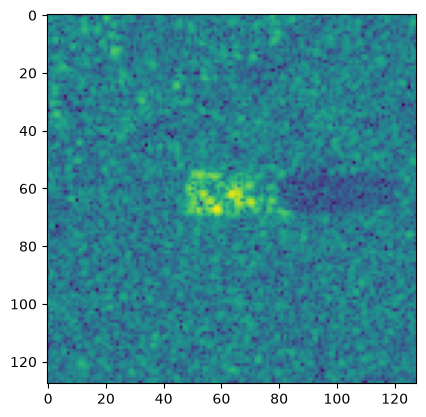

In [117]:
plt.imshow(meas_ds[0][0][0])

# Synth Image

In [88]:
no_aug_synth_ds = DatasetFolderWithPath(
    "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/synth",
    extensions = (".npy"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = dso_np_file_loader
)

In [89]:
len(no_aug_synth_ds)

5400

In [90]:
no_aug_synth_ds[0][0][0]

tensor([[2.8926e-16, 1.1570e-15, 7.0707e-16,  ..., 3.4068e-15, 1.0606e-15,
         1.6713e-15],
        [1.9284e-16, 1.5748e-15, 5.7851e-16,  ..., 2.7319e-15, 5.7851e-16,
         1.5748e-15],
        [2.8926e-16, 8.0349e-16, 8.9991e-16,  ..., 2.4426e-15, 1.0285e-15,
         6.7493e-16],
        ...,
        [9.3205e-16, 7.7135e-16, 8.3563e-16,  ..., 3.2140e-16, 1.0606e-15,
         1.2213e-15],
        [9.3205e-16, 1.3177e-15, 1.1249e-15,  ..., 1.9927e-15, 5.4637e-16,
         1.6713e-15],
        [7.0707e-16, 7.3921e-16, 1.0927e-15,  ..., 1.9927e-15, 8.0349e-16,
         1.1892e-15]])

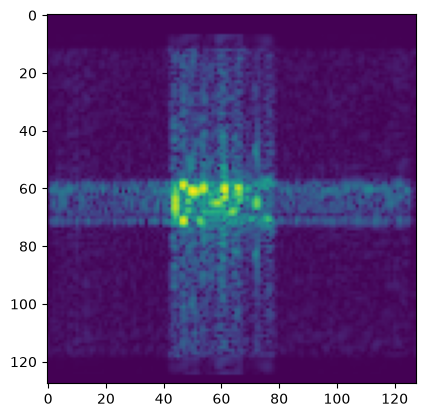

In [101]:
plt.imshow(no_aug_synth_ds[0][0][0])

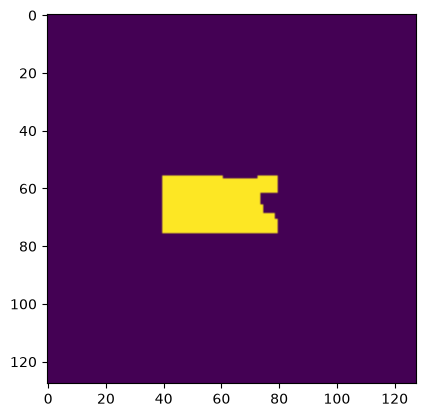

In [100]:
plt.imshow(np.load("/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/masks/npy_files/synth/2s1/2s1_synth_elevDeg_15_azCenter_0.npy"))

In [103]:
np.load("/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/masks/npy_files/synth/2s1/2s1_synth_elevDeg_15_azCenter_0.npy").shape

(128, 128)

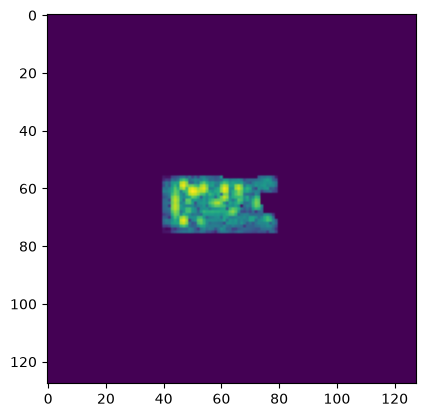

In [105]:
plt.imshow(no_aug_synth_ds[0][0][0].numpy() * np.load("/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/masks/npy_files/synth/2s1/2s1_synth_elevDeg_15_azCenter_0.npy"))